# 04 - Statystyki i Wizualizacja

Ten notebook obejmuje:
1. ewaluacje mIoU i IoU per klasa,
2. inference na real screenshotach z overlay,
3. dashboard metryk z MLflow.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image
import cv2
import mlflow
import torch

PROJECT_ROOT = Path.cwd().resolve()
import sys
if not (PROJECT_ROOT / 'src').exists():
    p = PROJECT_ROOT
    while True:
        if (p / 'src').exists():
            PROJECT_ROOT = p
            break
        if p == p.parent:
            break
        p = p.parent
sys.path.insert(0, str(PROJECT_ROOT))

TEST_DIR = PROJECT_ROOT / 'data' / 'segmentation' / 'test'
REAL_SCREENSHOTS_DIR = PROJECT_ROOT / 'src' / 'dataset' / 'Real_screenshots'
OUT_DIR = PROJECT_ROOT / 'data' / 'real_screenshot_predictions'
MODEL_PATH = PROJECT_ROOT / 'models' / 'segmentation_unet_strong.pt'
MLFLOW_DB = (PROJECT_ROOT / 'mlruns' / 'mlflow.db').resolve()
MLFLOW_TRACKING_URI = f'sqlite:///{MLFLOW_DB}'
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

from src.models.segmentation_detector import (
    SegmentationDetector, SegmentationDataset,
    extract_instances, remap_instances_to_image,
    detect_playfield_bbox, parse_hud_numbers, ID_TO_CLASS,
)
from src.utils.mlflow_logger import MLflowLogger

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('MODEL_PATH:', MODEL_PATH)
print('MLflow tracking URI:', MLFLOW_TRACKING_URI)


MODEL_PATH: /home/mwrona/PAC-MAN-AI/models/segmentation_unet_strong.pt
MLflow tracking URI: sqlite:////home/mwrona/PAC-MAN-AI/mlruns/mlflow.db


In [ ]:
def compute_miou(detector, dataset, id_to_class):
    class_ids = sorted(id_to_class.keys())
    intersection = {cid: 0 for cid in class_ids}
    union = {cid: 0 for cid in class_ids}
    for idx in range(len(dataset)):
        img_t, mask_t = dataset[idx]
        img_np = (img_t.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
        pred = detector.predict_mask(img_np)
        gt = mask_t.numpy().astype(np.int32)
        for cid in class_ids:
            if cid == 0:
                continue
            pred_c = (pred == cid).astype(np.uint8)
            gt_c = (gt == cid).astype(np.uint8)
            inter = int((pred_c & gt_c).sum())
            uni = int((pred_c | gt_c).sum())
            intersection[cid] += inter
            union[cid] += uni

    ious = {}
    for cid in class_ids:
        if cid == 0:
            continue
        if union[cid] > 0:
            ious[id_to_class[cid]] = float(intersection[cid]) / float(union[cid])
        else:
            ious[id_to_class[cid]] = None
    vals = [v for v in ious.values() if v is not None]
    miou = float(np.mean(vals)) if vals else None
    return ious, miou

if not MODEL_PATH.exists():
    print('Model not found:', MODEL_PATH)
else:
    detector = SegmentationDetector.load(MODEL_PATH, device=DEVICE)
    test_ds = SegmentationDataset(TEST_DIR)
    per_class_iou, miou = compute_miou(detector, test_ds, ID_TO_CLASS)
    print('mIoU:', miou)

    with MLflowLogger(experiment_name='segmentation_training', run_name='segmentation_eval') as logger:
        logger.log_params({'model_path': str(MODEL_PATH), 'dataset': str(TEST_DIR)})
        metric_payload = {'miou': float(miou) if miou is not None else np.nan}
        for label, value in per_class_iou.items():
            metric_payload[f'iou_{label}'] = float(value) if value is not None else np.nan
        logger.log_metrics(metric_payload)

    plot_items = [(k, v) for k, v in per_class_iou.items() if v is not None]
    if plot_items:
        labels, values = zip(*plot_items)
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.bar(labels, values, color='steelblue')
        ax.set_ylim(0, 1)
        ax.set_ylabel('IoU')
        ax.set_title(f'Per-class IoU (mIoU={miou:.3f})')
        ax.tick_params(axis='x', rotation=45)
        plt.tight_layout()
        plt.show()

In [ ]:
def _group_for_label(label: str) -> str:
    if label in {'blinky', 'pinky', 'inky', 'clyde', 'frightened_ghost', 'ghost_eyes'}:
        return 'ghosts'
    if label == 'fruit':
        return 'fruit'
    if label == 'pacman':
        return 'pacman'
    if label in {'pellet', 'power_pellet'}:
        return 'collectibles'
    return 'other'

GROUP_COLORS = {
    'pacman': '#ffd400',
    'ghosts': '#5ac8fa',
    'fruit': '#ff7a59',
    'collectibles': '#b8f397',
    'other': '#ffffff',
}

def show_annotated_image(image: np.ndarray, instances: list, playfield_bbox=None, figsize=(14, 12), show=True):
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.imshow(image)
    if playfield_bbox is not None:
        x0, y0, bw, bh = playfield_bbox
        ax.add_patch(Rectangle((x0, y0), bw, bh, fill=False, edgecolor='#00e5ff', linewidth=3))
    for obj in instances:
        x, y, w, h = obj['bbox']
        label = obj['label']
        color = GROUP_COLORS.get(_group_for_label(label), '#ffffff')
        ax.add_patch(Rectangle((x, y), w, h, fill=False, edgecolor=color, linewidth=2))
        ax.text(x, max(0, y - 6), label, color=color, fontsize=9, weight='bold',
                bbox=dict(facecolor='black', alpha=0.6, pad=1, edgecolor='none'))
    ax.axis('off')
    if show:
        plt.show()
    return fig, ax

if not MODEL_PATH.exists():
    print('Model not found:', MODEL_PATH)
else:
    detector = SegmentationDetector.load(MODEL_PATH, device=DEVICE)
    img_path = REAL_SCREENSHOTS_DIR / 'Screenshot_20260614_131655.png'
    image = np.asarray(Image.open(img_path).convert('RGB'), dtype=np.uint8)
    playfield_bbox = detect_playfield_bbox(image)
    x0, y0, bw, bh = playfield_bbox
    crop = image[y0:y0+bh, x0:x0+bw]
    resized = cv2.resize(crop, (224, 248), interpolation=cv2.INTER_AREA)
    pred_mask = detector.predict_mask(resized)

    instances_local = extract_instances(pred_mask, ID_TO_CLASS, min_area=10)
    instances = remap_instances_to_image(instances_local, playfield_bbox, pred_mask.shape)

    outdir = OUT_DIR / img_path.stem
    outdir.mkdir(parents=True, exist_ok=True)
    fig, _ = show_annotated_image(image, instances, playfield_bbox=playfield_bbox, show=True)
    fig.savefig(outdir / 'annotated_overlay.png', dpi=150, bbox_inches='tight')
    plt.close(fig)
    print('Saved overlay:', outdir / 'annotated_overlay.png')

In [ ]:
client = mlflow.tracking.MlflowClient(tracking_uri=MLFLOW_TRACKING_URI)
exp = client.get_experiment_by_name('segmentation_training')

if exp is None:
    print("Experiment 'segmentation_training' not found")
else:
    runs = client.search_runs(
        experiment_ids=[exp.experiment_id],
        order_by=['attributes.start_time DESC'],
        max_results=30,
    )

    rows = []
    for r in runs:
        rows.append({
            'run_name': r.data.tags.get('mlflow.runName', r.info.run_id[:8]),
            'status': r.info.status,
            'start_time': pd.to_datetime(r.info.start_time, unit='ms'),
            'train_loss': r.data.metrics.get('train_loss', np.nan),
            'val_loss': r.data.metrics.get('val_loss', np.nan),
            'best_val_loss': r.data.metrics.get('best_val_loss', np.nan),
            'miou': r.data.metrics.get('miou', np.nan),
            'n_instances': r.data.metrics.get('n_instances', np.nan),
        })

    df_runs = pd.DataFrame(rows)
    display(df_runs.head(20))

    if not df_runs.empty:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        train_df = df_runs.dropna(subset=['best_val_loss']).copy().sort_values('start_time')
        if not train_df.empty:
            axes[0].plot(train_df['start_time'], train_df['best_val_loss'], marker='o', color='tab:blue')
            axes[0].set_title('Best val loss over time')
            axes[0].set_ylabel('best_val_loss')
            axes[0].tick_params(axis='x', rotation=30)

        eval_df = df_runs.dropna(subset=['miou']).copy().sort_values('start_time')
        if not eval_df.empty:
            axes[1].plot(eval_df['start_time'], eval_df['miou'], marker='o', color='tab:green')
            axes[1].set_title('mIoU over time')
            axes[1].set_ylabel('mIoU')
            axes[1].set_ylim(0, 1)
            axes[1].tick_params(axis='x', rotation=30)

        plt.tight_layout()
        plt.show()

## Wizualna inspekcja detekcji na próbce z testu

Losowa próbka obrazów z `data/segmentation/test` — obok siebie: oryginalny frame i ten sam frame z kolorowymi boksami per klasa. Pomaga szybko ocenić, czy model poprawnie lokalizuje assety.


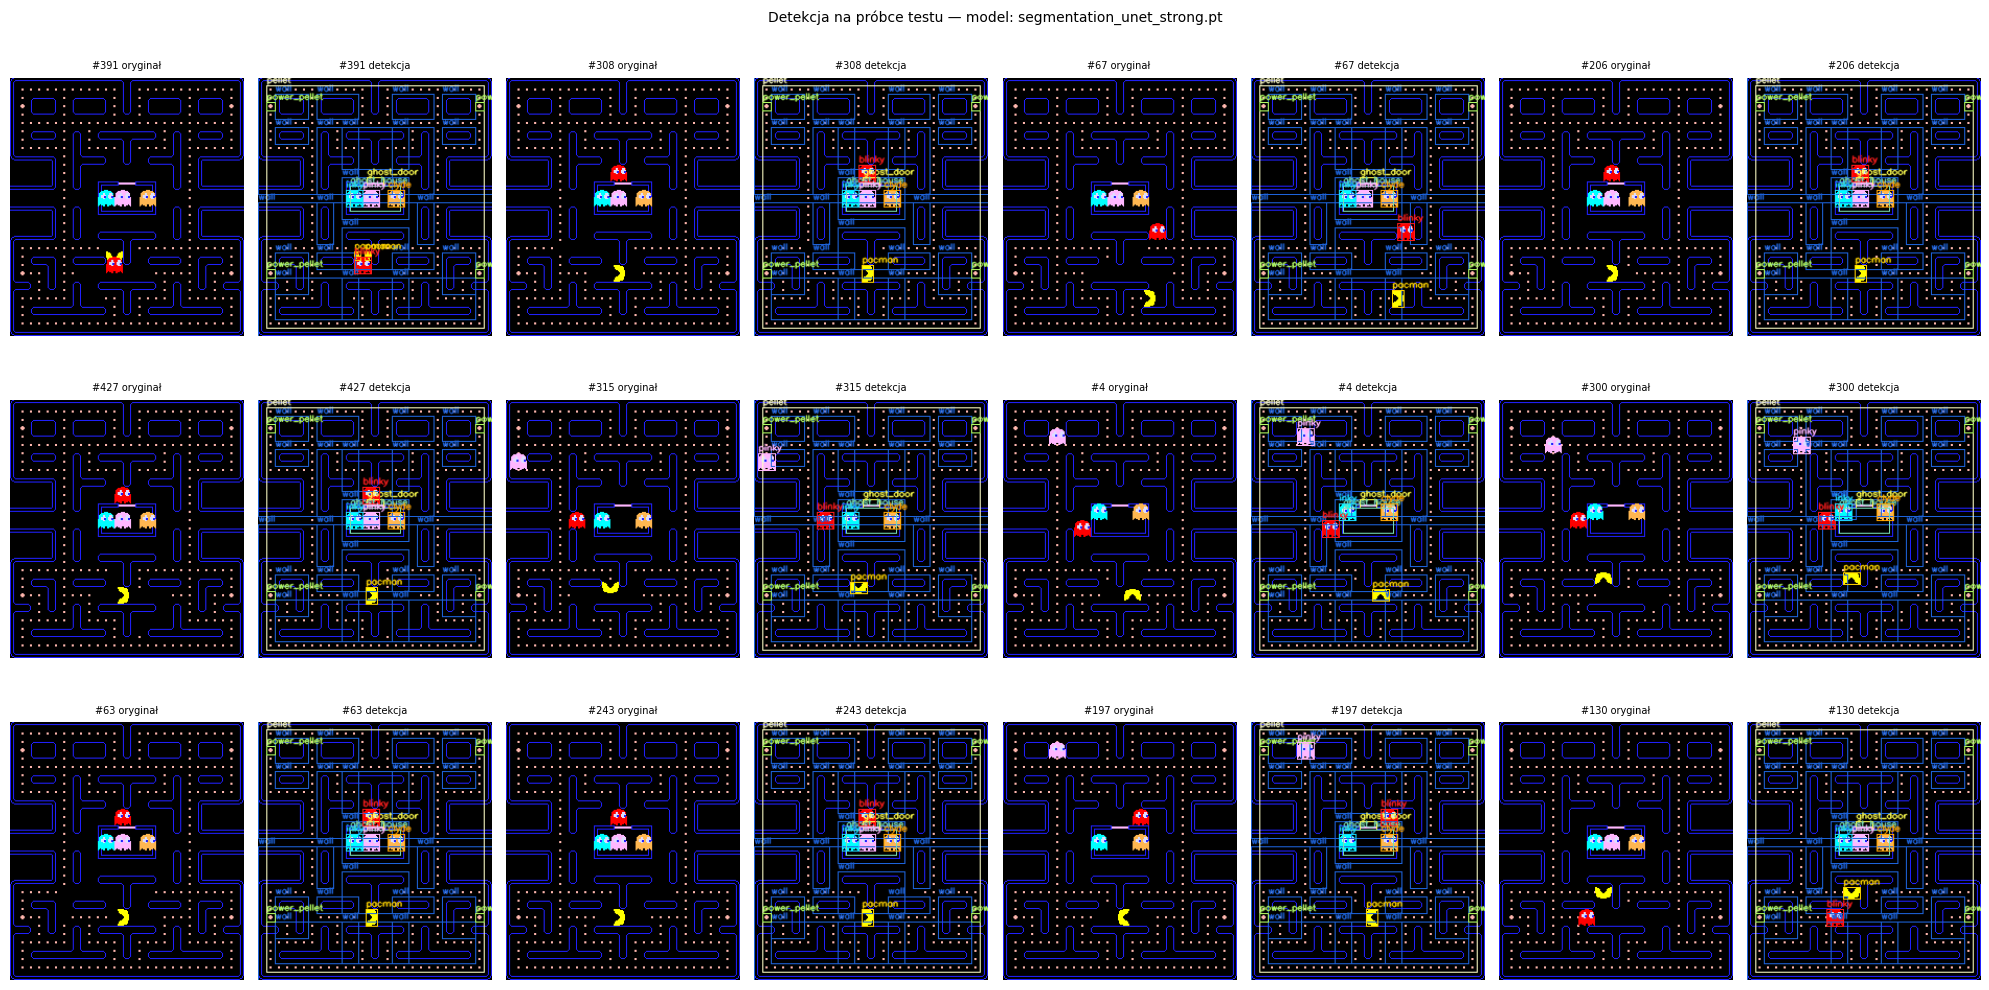

Zapisano 12 podglądów do: /home/mwrona/PAC-MAN-AI/data/real_screenshot_predictions/test_preview


In [2]:
import random

CLASS_COLORS = {
    'pacman':           (255, 212,   0),
    'blinky':           (255,  30,  30),
    'pinky':            (255, 180, 255),
    'inky':             ( 30, 220, 255),
    'clyde':            (255, 165,   0),
    'frightened_ghost': ( 50,  50, 255),
    'ghost_eyes':       (200, 200, 200),
    'pellet':           (255, 255, 200),
    'power_pellet':     (180, 255, 100),
    'fruit':            (255,  80,  80),
    'wall':             ( 30, 100, 220),
    'ghost_door':       (255, 255,  80),
    'ghost_house':      (120, 220, 180),
}

PREVIEW_SAMPLES = 12   # ile ramek pokazać w gridzie
SAVE_PREVIEWS = True   # zapisz PNG do data/real_screenshot_predictions/test_preview/
COLS = 4

def draw_detection_overlay(image_rgb: np.ndarray, pred_mask: np.ndarray, id_to_class: dict) -> np.ndarray:
    """Zwraca RGB image z nałożonymi kolorowymi boksami i etykietami."""
    vis = image_rgb.copy()
    instances = extract_instances(pred_mask, id_to_class, min_area=5)
    for obj in instances:
        x, y, w, h = [int(v) for v in obj['bbox']]
        label = obj['label']
        color = CLASS_COLORS.get(label, (230, 230, 230))
        cv2.rectangle(vis, (x, y), (x + w, y + h), color, 1)
        cv2.putText(vis, label, (x, max(0, y - 3)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.28, color, 1, cv2.LINE_AA)
    return vis


if not MODEL_PATH.exists():
    print('Model not found:', MODEL_PATH)
else:
    detector = SegmentationDetector.load(MODEL_PATH, device=DEVICE)
    test_ds = SegmentationDataset(TEST_DIR)

    indices = random.sample(range(len(test_ds)), min(PREVIEW_SAMPLES, len(test_ds)))
    rows_count = (len(indices) + COLS - 1) // COLS

    fig, axes = plt.subplots(rows_count, COLS * 2, figsize=(COLS * 5, rows_count * 3.5))
    axes = np.array(axes).reshape(rows_count, COLS * 2)

    for ax in axes.flat:
        ax.axis('off')

    save_dir = None
    if SAVE_PREVIEWS:
        save_dir = OUT_DIR / 'test_preview'
        save_dir.mkdir(parents=True, exist_ok=True)

    for plot_idx, ds_idx in enumerate(indices):
        row = plot_idx // COLS
        col = (plot_idx % COLS) * 2

        img_t, _mask_t = test_ds[ds_idx]
        img_np = (img_t.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
        pred_mask = detector.predict_mask(img_np)
        overlay = draw_detection_overlay(img_np, pred_mask, ID_TO_CLASS)

        axes[row, col].imshow(img_np)
        axes[row, col].set_title(f'#{ds_idx} oryginał', fontsize=7)
        axes[row, col + 1].imshow(overlay)
        axes[row, col + 1].set_title(f'#{ds_idx} detekcja', fontsize=7)

        if save_dir is not None:
            combined = np.concatenate([img_np, overlay], axis=1)
            Image.fromarray(combined).save(save_dir / f'sample_{ds_idx:04d}.png')

    plt.suptitle(f'Detekcja na próbce testu — model: {MODEL_PATH.name}', fontsize=10)
    plt.tight_layout()
    plt.show()

    if save_dir is not None:
        print(f'Zapisano {len(indices)} podglądów do: {save_dir}')


## Pellet mask — detekcja bez NN

Zamiast sieci neuronowej, pellety wykrywamy przez stałą maskę slotów wyprowadzoną
z mapy arcade (28×31). Dla każdego slotu sprawdzamy jasność piksela w frame —
jeśli jest wystarczająco jasny, pellet jest aktywny. Poniżej: maska wszystkich
możliwych slotów (lewy panel) i przykład detekcji na losowym frame (prawy panel).


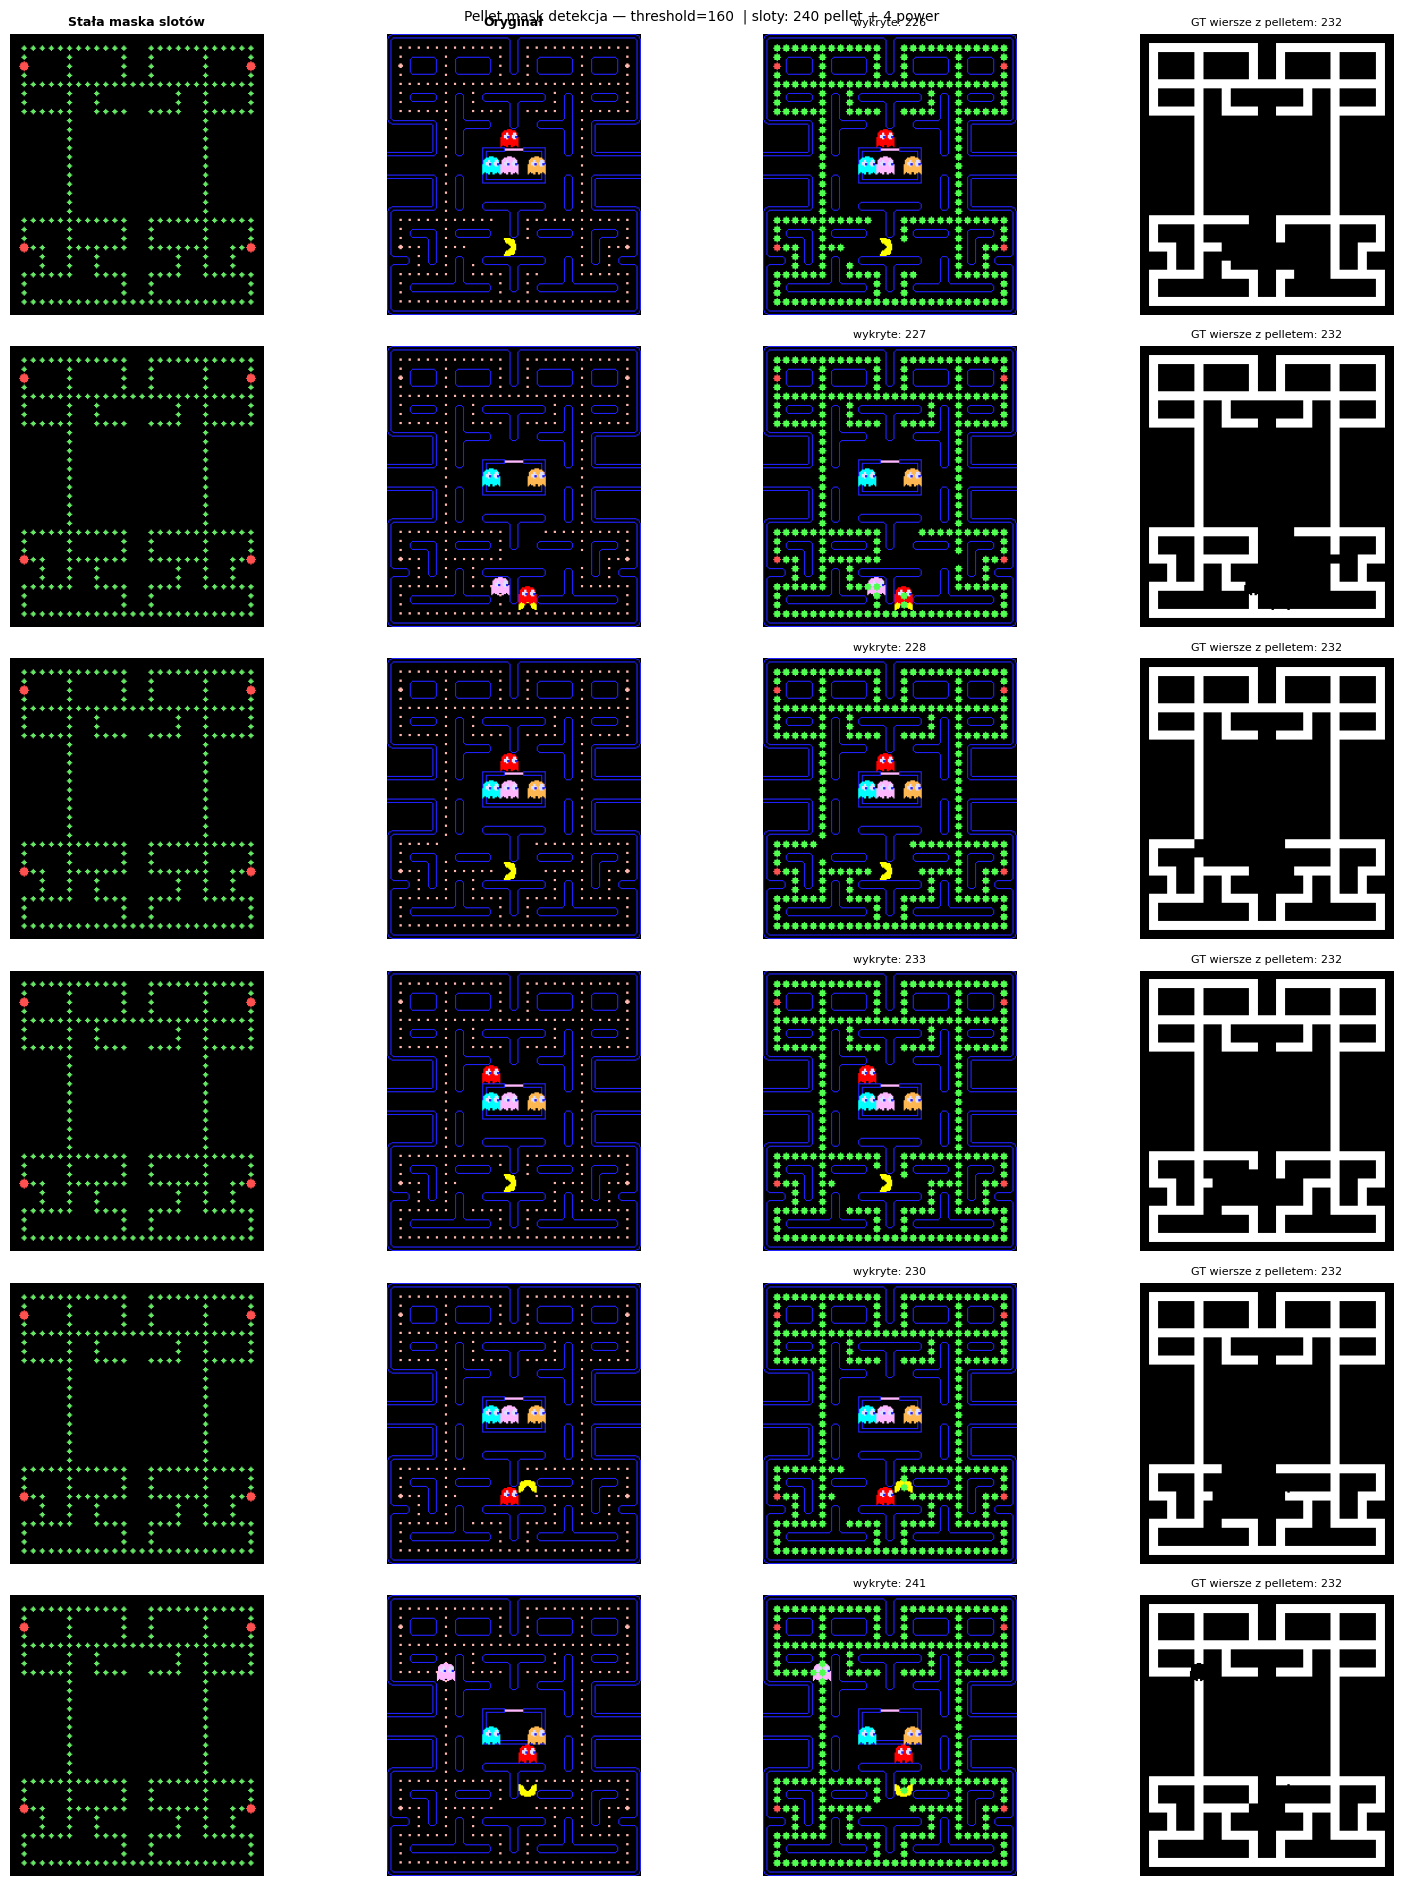

Łącznie slotów w masce: 240 pellet + 4 power = 244 aktywnych pozycji w labiryncie


In [2]:
from src.models.segmentation_detector import (
    build_pellet_slot_mask, detect_pellets_grid,
    _PELLET_SLOTS, _POWER_SLOTS,
)
from src.dataset.pacman_map_dataset import CLASS_TO_ID
import random as _rnd

BRIGHTNESS_THRESHOLD = 160   # prog jasnosci do uznania slotu za aktywny
N_COMPARE = 6                # ile ramek porownac z GT mask

test_imgs = sorted(TEST_DIR.glob('images/*.png'))
test_masks = sorted(TEST_DIR.glob('masks/*.png'))
samples = list(zip(test_imgs, test_masks))
_rnd.shuffle(samples)
samples = samples[:N_COMPARE]

# --- stala maska slotow -----------------------------------------------
slot_mask = build_pellet_slot_mask()   # 248x224, uint8

# Kolorowa wizualizacja maski (pellet=zielony, power=czerwony)
slot_vis = np.zeros((slot_mask.shape[0], slot_mask.shape[1], 3), dtype=np.uint8)
for r, c, cx, cy in _PELLET_SLOTS:
    cv2.circle(slot_vis, (cx, cy), 2, (100, 230, 100), -1)
for r, c, cx, cy in _POWER_SLOTS:
    cv2.circle(slot_vis, (cx, cy), 4, (255, 80, 80), -1)

# --- grid: maska slotów | frame | detekcja grid vs GT -----------------
fig, axes = plt.subplots(N_COMPARE, 4, figsize=(16, N_COMPARE * 3.2))
col_titles = ['Stała maska slotów', 'Oryginał', 'Grid detekcja (bez NN)', 'GT maska pelletów']
for ax, t in zip(axes[0], col_titles):
    ax.set_title(t, fontsize=9, weight='bold')

pellet_id = CLASS_TO_ID['pellet']
power_id  = CLASS_TO_ID['power_pellet']

for row_idx, (img_p, mask_p) in enumerate(samples):
    img_np = np.asarray(Image.open(img_p).convert('RGB'), dtype=np.uint8)
    gt_mask = np.asarray(Image.open(mask_p).convert('L'), dtype=np.uint8)

    # grid detekcja
    instances = detect_pellets_grid(img_np, brightness_threshold=BRIGHTNESS_THRESHOLD)

    # narysuj detekcje na kopii obrazu
    det_vis = img_np.copy()
    for obj in instances:
        x, y, w, h = [int(v) for v in obj['bbox']]
        color = (80, 255, 80) if obj['label'] == 'pellet' else (255, 80, 80)
        cx_i, cy_i = int(obj['centroid'][0]), int(obj['centroid'][1])
        cv2.circle(det_vis, (cx_i, cy_i), 3, color, -1)

    # GT — pellet i power jako binarna maska
    gt_vis = np.zeros_like(gt_mask)
    gt_vis[(gt_mask == pellet_id) | (gt_mask == power_id)] = 255

    for ax in axes[row_idx]:
        ax.axis('off')

    axes[row_idx, 0].imshow(slot_vis)
    axes[row_idx, 1].imshow(img_np)
    axes[row_idx, 2].imshow(det_vis)
    axes[row_idx, 3].imshow(gt_vis, cmap='gray')

    # statystyki detekcji vs GT
    n_det = len(instances)
    n_gt = int(((gt_mask == pellet_id) | (gt_mask == power_id)).any(axis=1).sum())
    axes[row_idx, 2].set_title(f'wykryte: {n_det}', fontsize=8)
    axes[row_idx, 3].set_title(f'GT wiersze z pelletem: {n_gt}', fontsize=8)

plt.suptitle(
    f'Pellet mask detekcja — threshold={BRIGHTNESS_THRESHOLD}  '
    f'| sloty: {len(_PELLET_SLOTS)} pellet + {len(_POWER_SLOTS)} power',
    fontsize=10,
)
plt.tight_layout()
plt.show()

print(f"Łącznie slotów w masce: {len(_PELLET_SLOTS)} pellet + {len(_POWER_SLOTS)} power = {len(_PELLET_SLOTS)+len(_POWER_SLOTS)} aktywnych pozycji w labiryncie")
